## 前言
https://codetop.cc/home

力扣 算法 前100 高频考查题 

---

### 215. 数组中的第K个最大元素
> 给定整数数组 nums 和整数 k，请返回数组中第 k 个最大的元素。时间复杂度为 O(n)

思路：在遍历数组的同时维护一个大小为k的最小堆，遍历完成的时候，最小堆的堆首元素就是top-k。那对于小于小堆队首的元素扔掉就好了，没什么用

In [8]:
import heapq

def findKthLargest(nums, k):
    min_head = []
    
    for x in nums:
        if len(min_head)< k:
            heapq.heappush(min_head,x)
        elif x > min_head[0]:  # 当遇到更大的值的时候才入堆
            heapq.heappushpop(min_head, x)
    
    return min_head[0]

nums = [3,2,1,5,6,4]
k = 2
findKthLargest(nums, k)

5

### 3. 无重复字符的最长子串
>给定一个字符串 s ，请你找出其中不含有重复字符的最长子串的长度。

思路：滑动窗口。左侧窗口收缩条件是：遇到在字典中的元素， 右指针是当前数的下标。

疑问：为什么左指针要收缩到最大的呢？因为左指针是不断往右的，用一个max() 防止左指针走回头路  

坑点：判断窗口收缩之前不能更新字典


In [16]:
def lengthOfLongestSubstring(s):
    seen = {}
    
    # 同时获取下标和元素，单不改变元素的值，用enumerate()
    left = -1
    result = 0
    for right, x in enumerate(s):
        if x in seen:   #窗口收缩
            left = max(left , seen[x])
            
        seen[x] = right  #会记录最近的字符出现的位置, 这里当做窗口右指针
        # 记录结果
        result = max(result,right-left)
    return result
# s = "abcabcbb"
s = "abba"
lengthOfLongestSubstring(s)

2

### 72. 编辑距离
>给定两个单词 word1 和 word2， 返回将 word1 转换成 word2 所使用的最少操作数。可以对word1进行的操作有 插入新字符、删除、替换

思路：动态规划。状态转移方程方程: min(dp[i-1][j-1], dp[i-1][j] , dp[i][j-1]) + 1. 这题和1143. 最长公共子序列是一个算法模版

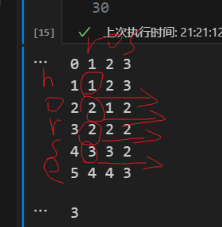

trick: 在处理字符串的时候，往往生成的是下标访问，要养成下标访问的习惯，灵活性更大

In [15]:
def minDistance(word1, word2):
    n, m = len(word1), len(word2)
    
    dp = [[0] * (m +1) for _ in range(n+1)]
    # print(dp)
    
    # 状态转移： 首付首列
    for i in range(1,n+1):
        dp[i][0] = i
    for j in range(1,m+1):
        dp[0][j] = j
    # print(dp)
    
    for i in range(1,n+1):
        for j in range(1,m+1):
            if word1[i-1] == word2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(dp[i-1][j-1], dp[i-1][j] , dp[i][j-1]) + 1
    
    for row in dp:
        print(*row)    
    return dp[n][m]
        
    

word1 = "horse"
word2 = "ros"
minDistance(word1, word2)


0 1 2 3
1 1 2 3
2 2 1 2
3 2 2 2
4 3 3 2
5 4 4 3


3

In [21]:
# 空间优化

def minDistance(word1, word2):
    n, m = len(word1), len(word2)
    
    dp = [0] * (m +1) 
    # print(dp)
    
    # 状态转移： 首行
    for j in range(1,m+1):
        dp[j] = j
    # print(dp)
    
    for i in range(1,n+1):
        leftup = dp[0]
        dp[0] += 1
        for j in range(1,m+1):
            temp = dp[j]
            if word1[i-1] == word2[j-1]:
                dp[j] = leftup
            else:
                dp[j] = min(leftup, dp[j] , dp[j-1]) + 1
            leftup = temp
    # print(*dp)    
    return dp[m]
        
    

word1 = "horse"
word2 = "ros"
minDistance(word1, word2)

3

> python 从矩阵中得到列元素的几种方法
- 列表生成式
- zip(*)
- 转成numpy, 这个支持二维切片取列，python原生的列表不支持

In [9]:
matrix = [[1,2,3],[4,5,6]]
col = [row[1] for row in matrix]  
col

[2, 5]

### 53. 最大子数组和
>给定整数数组 nums，找出一个具有最大和的连续子数组，返回其最大和。

思路：序列动态规划。 如下图，使用正向遍历。dp表空间优化为一个变量，最优子结构是dp[i],历史最大值dp[i]和当前最大值中最大的一个。当前最大值计算:当dp值为负的时候，说明要重新计数了。  
直接求解不出，要用间接求

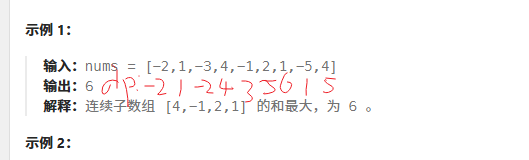

In [2]:
def maxSubArray(nums):
    dp = nums[0]
    result = float('-inf')
    for i in range(1, len(nums)):
        dp = dp+nums[i] if dp > 0 else nums[i]
        # 间接取值，不是最后一个dp[-1]。
        result = max(result,dp)
    
    return result

nums = [-2,1,-3,4,-1,2,1,-5,4]

### 200. 岛屿数量
> 给你一个由 '1'（陆地）和 '0'（水）组成的的二维网格，请你计算网格中岛屿的数量。

思路：图的DFS-迭代版本。

In [3]:
def numIslands(grid) -> int:
    def dfs_iter(i,j):
        visited = [(i,j)]
        while visited:
            i,j = visited.pop()
            if grid[i][j] == '1':
                if i-1 >=0:
                    visited.append((i-1, j))
                if j-1 >=0:
                    visited.append((i, j-1))
                if i+1 <n:
                    visited.append((i+1, j))
                if j +1 <m:
                    visited.append((i, j+1))
                # post
                grid[i][j] = '0'
    
    n,m = len(grid), len(grid[0])
    islands_cnt = 0
    for i in range(n):
        for j in range(m):
            if grid[i][j] == '1':
                islands_cnt += 1
                dfs_iter(i,j)
                
    return islands_cnt

grid = [
  ['1','1','1','1','0'],
  ['1','1','0','1','0'],
  ['1','1','0','0','0'],
  ['0','0','0','0','0']
]

numIslands(grid)

1

### 15. 三数之和
>两数之和升级版。找出整数数组 nums中，三个互不相同的下标i,j,k. 其对应的值的和为0。所有的这样的组合。

- 思路：先排序，然后利用双指针。遍历一遍数组，下标为k, 双指针i,j交替往中间移动。

In [27]:
def threeSum(nums):
    nums.sort()
    results = []
    for k in range(len(nums)-2):
        if nums[k]>0:  # 因为 k < i < j
            break
        if k>0 and nums[k] == nums[k-1]:  # skip
            continue
        i,j = k+1, len(nums)-1
        while i<j:
            target = nums[i] + nums[j] + nums[k]
            if target ==0:
                results.append([nums[k],nums[i], nums[j]])
                i += 1
                j -= 1
                while i<j and nums[i] == nums[i-1]: i+=1
                while i<j and nums[j] == nums[j+1]: j-=1
            elif target < 0:
                i += 1
                while i<j and nums[i] == nums[i-1]: i+=1
            elif target > 0:
                j -= 1
                while i<j and nums[j] == nums[j+1]: j-=1
        # print(k)
    return results
        

nums = [-1,0,1,2,-1,-4,-1]
threeSum(nums)

[[-1, -1, 2], [-1, 0, 1]]

### 33. 搜索旋转排序数组
> 整数数组 nums 按升序排列，数组中的值 互不相同。  
> nums 在预先未知的某个下标 k（0 <= k < nums.length）上进行了 向左旋转。  
> 如果 nums 中存在目标值 target ，则返回它的下标，否则返回 -1 。

思路：如果 nums[mid] >= nums[left]，肯定是左半区间有序。nums[mid] <= nums[right-1]肯定是右半区间有序。使用模版1

坑点：找到左半区有两种写法。右半区也类似
- nums[mid] >= nums[left]
- nums[mid] > nums[l]


In [21]:
def search(nums, target: int) -> int:
    l,r = 0, len(nums)-1
    while l <= r:
        mid = l + (r-l) // 2
        if nums[mid] == target:
            return mid
        elif nums[mid] < target:  # 目标值大于中间值
            # 找出有序的半区
            if nums[mid] <= nums[r] and target > nums[r]:  # 右半区有序, 这个时候target比右半区所有的都大，所以target在左半区
                r = mid-1
            else:
                l = mid +1
        else:
            if nums[mid] >= nums[l] and target < nums[l]:  #左半区有序
                l = mid +1
            else:
                r = mid-1
    
    return -1

# nums = [4,5,6,7,0,1,2]
nums = [3,1]
target = 3
search(nums, target)

0

### 206. 反转链表
> 给你单链表的头节点 head ，请你反转链表，并返回反转后的链表。

- 思路：头插法。new_head=None, 每次从原链表脱落的节点就是new_head

思考：反转局部链表应该怎么操作？

In [22]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next
def reverseList(head):
    if not head or not head.next: return head
    
    curr, new_head = head,None
    while curr:
        tmp = curr.next
        curr.next = new_head
        new_head = curr
        curr = tmp
        
    return new_head
        

bisect 是 Python 标准库 里的一个模块，主要用来对有序列表进行 二分查找和插入。
1. 查找位置(手动实现可以做)
   - bisect.bisect_left(a, x), 找到最左边的插入位置
   - bisect.bisect_right(a, x)
2. 插入元素(手动实现：创建一个新的数组，切片后留出位置)
   - bisect.insort(a, x)

In [62]:
import bisect

def search(seq,target):
        # 二分查找插入位置。模版1
        l, r = 0,len(seq)-1
        while l<=r:
            m = l + (r-l) // 2
            if seq[m] == target:
                return m
            elif seq[m] < target:
                l = m +1
            else:
                r = m- 1
        
        return l

nums = [10]
x = 12
bisect.bisect_left(nums, x), search(nums,x)
# bisect.insort_left(nums, x)
# bisect.insort(nums, x)
# nums


(1, 1)

### 300. 最长递增子序列
> 给你一个整数数组 nums ，找到其中最长严格递增子序列的长度。

思路：动态规划+bisect。通过bisect维护一个序列，序列中的元素是严格递增的。序列的长度就是每个子问题的解。

In [64]:
import bisect
def lengthOfLIS(nums):
    def search(sequence,target):
        # 二分查找插入位置。模版1
        l, r = 0,len(sequence)-1
        while l<=r:
            m = l + (r-l) // 2
            if sequence[m] == target:
                return m
            elif sequence[m] < target:
                l = m +1
            else:
                r = m- 1
        
        return l
    
    
    seq = [nums[0]]
    for i in range(1, len(nums)):
        new_idx = search(seq, nums[i])
        if new_idx == len(seq):  #比最大的元素还要大
            seq.append(nums[i])
        else:
            seq[new_idx] = nums[i]
        
    print(seq)
    return len(seq)

nums = [10,9,2,5,3,7,101,18]
lengthOfLIS(nums)

[2, 3, 7, 18]


4

### 46. 全排列
> 给定一个不含重复数字的数组 nums ，返回其所有可能的全排列 。你可以 按任意顺序 返回答案。

- 思路： 回朔法。visited= [False]*N 用于剪枝。
  
思考：数组中含有重复元素，应该怎么处理。

In [77]:
def permute(nums):
    results = []
    N = len(nums)
    visited = [False]*N
    def backtrack(start=0, path=[]):
        if len(path) == N:
            results.append(path[:])
            return

        for i in range(0,N):
            # 剪枝
            if not visited[i]:
                path.append(nums[i])
                visited[i] = True
                backtrack(i+1)
                path.pop()
                visited[i] = False
                
    backtrack()
    
    return results
nums = [1,2,3]
permute(nums)

[[1, 2, 3], [1, 3, 2], [2, 1, 3], [2, 3, 1], [3, 1, 2], [3, 2, 1]]

### 手撕快排（912. 排序数组）
> 给你一个整数数组 nums，请你将该数组升序排列。

思路：这题考察的快速排序的写法。快排的核心哨兵划分。

- 基准数优化.随机。


In [ ]:
import random
def partition(nums,left, right):
    pivot_idx = random.randint(left, right)
    nums[left], nums[pivot_idx] = nums[pivot_idx], nums[left]

    i,j = left, right
    while i<j:
        while i <j and nums[j] >= nums[left]:
            j -= 1  # 要先找这个，不能把j放后面
        while i < j and nums[i] <= nums[left]:
            i += 1
        if i<j:
            nums[i],nums[j] = nums[j],nums[i]
    
    nums[i], nums[left] = nums[left], nums[i]
    
    return i

def sortArray(nums,i,j):
    if i>=j : return
    pivot_idx = partition(nums,i,j)
    sortArray(nums,i,pivot_idx-1)
    sortArray(nums,pivot_idx+1,j)
        
nums = [5,2,3,2,2,2,1]
sortArray(nums,0,len(nums)-1)
nums


[1, 2, 2, 2, 2, 3, 5]

- 面对大量重复的数时，需要用到三路快排

In [9]:
import random
def sortArray(nums):
    def partition(nums,left,right):
        # 哨兵划分
        # 三路快排
        pivot_idx = random.randint(left, right)
        nums[left], nums[pivot_idx] = nums[pivot_idx], nums[left]
        pivot = nums[left]

        low, cur, high = left, left+1, right
        while cur<=high:
            if nums[cur] < pivot:
                nums[low], nums[cur] = nums[cur], nums[low]
                low += 1
                cur += 1
            elif nums[cur] > pivot:
                nums[cur], nums[high] = nums[high], nums[cur]
                high -= 1
            else:
                cur += 1

        return low, high

    def quick_sort(nums,left,right):
        if left >= right:
            return
        low, high = partition(nums, left, right)
        quick_sort(nums, left, low - 1)   # 递归左区间
        quick_sort(nums, high + 1, right) # 递归右区间
    
    quick_sort(nums,0,len(nums)-1)

    return nums
nums = [5,2,2,2,2,3,1]
sortArray(nums)
nums

[1, 2, 2, 2, 2, 3, 5]

### 5. 最长回文子串
>给你一个字符串 s，找到 s 中最长的回文子串。

- 思路：枚举所有的「回文中心」并尝试「扩展」，直到无法扩展为止，此时的回文串长度即为此「回文中心」下的最长回文串长度。

核心是实现expandAroundCenter(s,left,right)。

偶数奇数Even  Odd


In [22]:
def longestPalindrome(s: str) -> str:
    def expandAroundCenter(s,left, right):
        # 中心扩展
        while left>=0 and right<len(s) and s[left] == s[right]:
            left -= 1
            right += 1
        
        return left + 1, right - 1
    
    start, end = 0,0
    for i in range(len(s)):
        even_left,even_right = expandAroundCenter(s,i,i)
        odd_left, odd_right = expandAroundCenter(s, i, i+1)
        if even_right-even_left > end-start:
            start, end = even_left,even_right
        if odd_right-odd_left > end-start:
            start, end = odd_left, odd_right
    
    return s[start:end+1]
        

s = "babad"
longestPalindrome(s)

'bab'

### 1143. 最长公共子序列
> 给定两个字符串 text1 和 text2，返回这两个字符串的最长 公共子序列 的长度。如果不存在 公共子序列，返回 0 。

- 思路：这题和72编辑距离是一个模版做法。一下子掌握了两个题。这里的状态转移矩阵是：max(dp[i][j-1], dp[i-1][j]), 和dp[i-1][j-1] + 1。

In [52]:
def longestCommonSubsequence(text1: str, text2: str) -> int:
    if len(text1) < len(text2):
        text1, text2 = text2, text1
        
    n,m = len(text1), len(text2)
    dp = [[0]*m for _ in range(n)]
    dp[0][0] = int(text1[0] == text2[0])
    # print(dp)
    # 初始化首行
    for j in range(1,m):
        dp[0][j] = 1 if text1[0] == text2[j] else dp[0][j-1]
    # 初始化首列
    for i in range(1,n):
        dp[i][0] = 1 if text1[i] == text2[0] else dp[i-1][0]
    # print(dp)
    
    for i in range(1,n):
        for j in range(1,m):
            if text1[i] == text2[j]:
                dp[i][j] = dp[i-1][j-1]+1
            else:
                dp[i][j] = max(dp[i][j-1], dp[i-1][j])
    
    for row in dp:
        print(*row)
    
    return dp[n-1][m-1]
    
    
# text1 = "abcde"
# text2 = "ace" 
text1 = "bsbininm"
text2 = "jmjkbkjkv"
longestCommonSubsequence(text1, text2)

0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 1
0 0 0 0 0 0 0 1
0 0 0 0 0 0 0 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1


1

- 空间优化。二维dp转为一维dp
  
在代码里面，print()是非常耗时的。经常出现由于print()的存在导致性能下降或者超时。

In [57]:
def longestCommonSubsequence(text1: str, text2: str) -> int:
    if len(text1) < len(text2):
        text1, text2 = text2, text1
        
    n,m = len(text1), len(text2)
    dp = [0]*m
    dp[0] = int(text1[0] == text2[0])
    # print(dp)
    # 初始化首行
    for j in range(1,m):
        dp[j] = 1 if text1[0] == text2[j] else dp[j-1]
    
    for i in range(1,n):
        left_up = dp[0]
        dp[0] = 1 if text1[i] == text2[0] or dp[0]==1 else 0
        for j in range(1,m):
            tmp = dp[j]
            if text1[i] == text2[j]:
                dp[j] = left_up+1
            else:
                dp[j] = max(dp[j], dp[j-1])
            left_up = tmp

        print(*dp)

    
    return dp[m-1]
    
    
# text1 = "abcde"
# text2 = "ace" 
text1 = "bsbininm"
text2 = "jmjkbkjkv"
longestCommonSubsequence(text1, text2)

0 0 0 0 0 0 0 1
0 0 0 0 0 0 0 1
0 0 0 0 0 0 0 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1
1 1 1 1 1 1 1 1


1

### 69. x 的平方根 
>不用math.sqrt(x), 计算出x的算术平方根(结果只保留整数部分)

- 思路：二分查找。

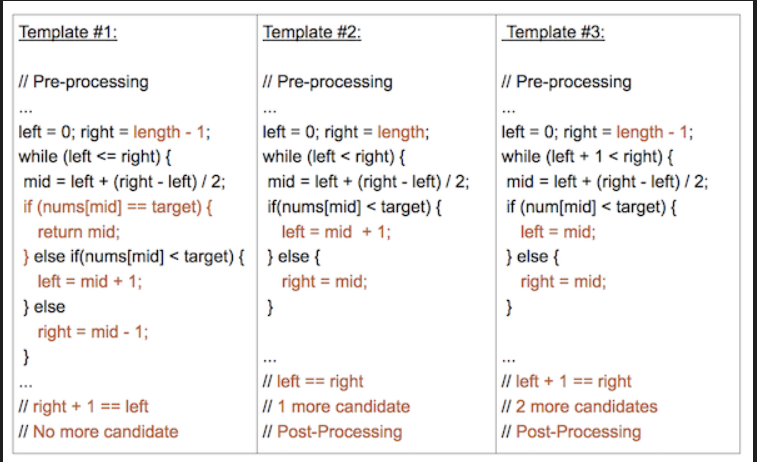

- 模版3

In [15]:
import math
def mySqrt(x):
    left, right = 0, x+1
    while left +1 <right:
        mid = left + (right- left) // 2
        if mid * mid <= x:
            left = mid
        else:
            right = mid
            
    return left
x = 20
mySqrt(x) == math.isqrt(x)
    

True

- 模版1

In [19]:
import math
def mySqrt(x):
    left, right = 0, x+1
    while left <=right:
        mid = left + (right- left) // 2
        if mid * mid == x:
            return mid
        elif mid * mid < x:
            left = mid + 1
        else:
            right = mid - 1
            
    return right
x = 3
mySqrt(x) == math.isqrt(x)

True

### 121. 买卖股票的最佳时机
> 你只能选择 某一天 买入这只股票，并选择在 未来的某一个不同的日子 卖出该股票。计算你所能获取的最大利润。

思路：只能买卖一次。序列dp, dp[i]是当前i状态下的最大利润.状态转移dp[i] = max(dp[i-1], 当前出售的利润)

思考：买卖两次，最大利润是多少？买卖n次最大利润是多少？

In [70]:
def maxProfit(prices) -> int:
    dp = [0]*len(prices)
    # 初始化
    visited_min = prices[0] # 辅助记录浏览过的最小值
    dp[0] = prices[0]- visited_min
    for i in range(1,len(prices)):
        visited_min = min(visited_min, prices[i])
        dp[i] = max(dp[i-1], prices[i]-visited_min) 
        print(*dp)
    
    return dp[-1]

prices = [7,1,5,3,6,4]
maxProfit(prices)


0 0 0 0 0 0
0 0 4 0 0 0
0 0 4 4 0 0
0 0 4 4 5 0
0 0 4 4 5 5


5

- 空间优化。一维dp变成常量

In [73]:
def maxProfit(prices) -> int:
    dp = [0]*len(prices)
    # 初始化
    visited_min = prices[0] # 辅助记录浏览过的最小值
    dp = prices[0]- visited_min
    for i in range(1,len(prices)):
        visited_min = min(visited_min, prices[i])
        dp = max(dp, prices[i]-visited_min) 
        # print(dp)
    
    return dp

prices = [7,1,5,3,6,4]
maxProfit(prices)

5

- 本题还有一种解法，单挑递增栈。这里省略代码

### 239. 滑动窗口最大值
> 给你一个整数数组 nums，有一个大小为 k 的滑动窗口从数组的最左侧移动到数组的最右侧。你只可以看到在滑动窗口内的 k 个数字。滑动窗口每次只向右移动一位。返回 滑动窗口中的最大值 。

思路：最典型的滑动窗口模版题。 使用max() 函数会超时。这个题和3. 无重复字符的最长子串很像: 本题用的是单调递减队列+滑动窗口， 那个题是哈希集合+滑动窗口。  
解题思路：通过单调递减队列，使得队列首元素一直是窗口内最大的元素。但是，不及时的将这个最大出队，就会导致窗口最大值出错。通过比较队首元素和当前数的下标，是一个可以使得首元素出队。  
所以这里不是将元素入队，虽然比较的是元素大小，但是入队的是元素下标，这样就自然而然的可以解决首元素出队的问题。另外这个时间复杂度是最好是O(N),最差是O(N)

#### 模版
需要变化的地方
- 1、右指针右移之后窗口数据更新
- 2、判断窗口是否要收缩
- 3、左指针右移之后窗口数据更新
- 4、根据题意计算结果

In [ ]:
import collections
def maxSlidingWindow(nums, k: int):
    deque = collections.deque()  #单调递减队列, 首元素就是最大值
    results = []
    for i in range(len(nums)):
        while deque and nums[i] > nums[deque[-1]]: # 维护单调递减队列
            deque.pop()
        deque.append(i) # 下标入队。右指针右移
            
        if deque[0] == i-k: # 左窗口移动
            deque.popleft()
        
        print(deque)
        if i>k-2: # 根据题意计算结果
            results.append(nums[deque[0]])
            
    return results
            
            
nums = [1,3,-1,-3,5,3,6,7]
k = 3
maxSlidingWindow(nums, k)

deque([0])
deque([1])
deque([1, 2])
deque([1, 2, 3])
deque([4])
deque([4, 5])
deque([6])
deque([7])


[3, 3, 5, 5, 6, 7]

### 25. K 个一组翻转链表
> 给你链表的头节点 head ，每 k 个节点一组进行翻转，请你返回修改后的链表。

思路：链表反转-》 局部反转 -》 k个一组反转。尾插法：每次掉落的节点连接到新链表的尾部

字节手撕题。

https://leetcode.cn/problems/reverse-nodes-in-k-group/solutions/248591/k-ge-yi-zu-fan-zhuan-lian-biao-by-leetcode-solutio/

In [26]:
class ListNode:
    def __init__(self, val=0, next=None):
        self.val = val
        self.next = next

def reverseKGroup(head,k):
    # 翻转一个子链表，并且返回新的头与尾
    def reverse(head: ListNode, tail: ListNode):
        prev = tail.next
        p = head
        while prev != tail:
            nex = p.next
            p.next = prev
            prev = p
            p = nex
        return tail, head
    
    
    dummy = ListNode(next=head)
    pre =dummy
    
    while head:
        tail = pre
        # 查看剩余部分长度是否大于等于 k
        for i in range(k):
            tail = tail.next
            if not tail:
                return dummy.next
        
        nex = tail.next
        head, tail = reverse(head, tail)
        # 把子链表重新接回原链表
        pre.next = head
        tail.next = nex
        pre = tail
        head = tail.next
        
    return dummy.next

### 92. 反转链表 II
>给你单链表的头指针 head 和两个整数 left 和 right ，其中 left <= right 。请你反转从位置 left 到位置 right 的链表节点，返回 反转后的链表 。

- 思路：翻转一个子链表，并且返回新的头与尾。这个函数reverse(head, tail)也可以用在反转链表个k个一组反转链表中

In [29]:
def reverseBetween(head, left: int, right: int):
    def reverse(head: ListNode, tail: ListNode):
        # 翻转一个子链表，并且返回新的头与尾
        prev = tail.next
        p = head
        while prev != tail:
            nex = p.next
            p.next = prev
            prev = p
            p = nex
        return tail, head
    
    # 主逻辑
    dummy = ListNode(next=head)
    prev,tail = dummy, head
    for _ in range(left-1):
        prev = prev.next
        head = head.next
        tail = tail.next
    for _ in range(right-left):
        tail = tail.next
    nex = tail.next
    head, tail = reverse(head, tail)
    
    prev.next = head #重新链接
    tail = nex

    return dummy.next

### 54. 螺旋矩阵
> 给你一个 m 行 n 列的矩阵 matrix ，请按照 顺时针螺旋顺序 ，返回矩阵中的所有元素。

思路：这是一个考察设计思路的题，也叫模拟题，这类提醒一不小心就会加入了很多判断。用一个visited矩阵

In [ ]:
def spiralOrder(matrix):
    if not matrix or not matrix[0]: return []
    
    rows, columns = len(matrix), len(matrix[0])
    visited = [[0]*columns for _ in range(rows)]
    total = rows * columns
    order = [0]*total
    
    directions = [[0,1],[1,0],[0,-1],[-1,0]] # 方向，右下左上
    for i in range(total):
    
    return total
        
   
    
matrix = [[1,2,3],[4,5,6],[7,8,9]]
spiralOrder(matrix)


9